# Student Dropout and Academic Success Prediction Using Machine Learning

## Project Overview

This project analyzes student demographic, academic, financial, and enrollment-related information to understand patterns associated with student outcomes.

The objective is to develop a machine learning classification model that predicts a student's academic outcome as:

- Dropout
- Enrolled
- Graduate

The project includes data preprocessing, exploratory data analysis, machine learning model development, evaluation, and sample prediction.

# Student Dropout and Academic Success Prediction Using Machine Learning

## Project Overview

This project analyzes student demographic, academic, financial, and enrollment-related information to understand patterns associated with student outcomes.

The objective is to develop a machine learning classification model that predicts a student's academic outcome as:

- Dropout
- Enrolled
- Graduate

The project includes data preprocessing, exploratory data analysis, machine learning model development, evaluation, and sample prediction.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
df = pd.read_csv("Data/predice student dropout and academic sucess dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (4424, 35)


In [6]:
print("First 5 records:")
display(df.head())

First 5 records:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [7]:
print("First 5 records:")
display(df.head())

First 5 records:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [8]:
print("Missing values:")
display(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values:


Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrollment                                 0
International                                     0
Curricular u


Total missing values: 0


In [9]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [10]:
print("Target distribution:")
display(df["Target"].value_counts())

print("\nTarget distribution (%):")
display(df["Target"].value_counts(normalize=True).mul(100).round(2))

Target distribution:


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


Target distribution (%):


Target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64

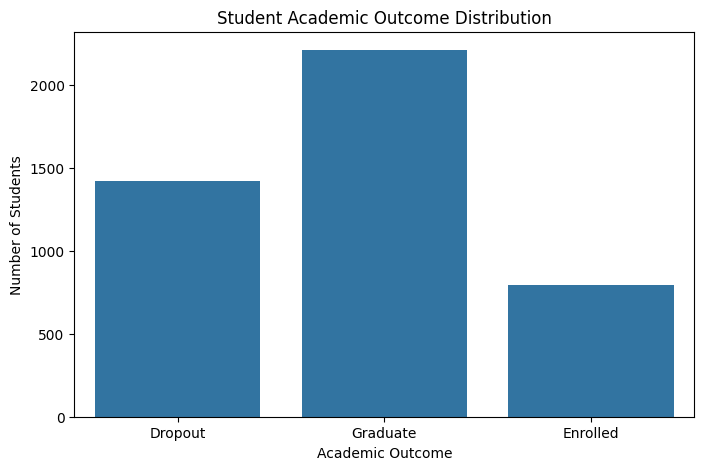

In [11]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Target")

plt.title("Student Academic Outcome Distribution")
plt.xlabel("Academic Outcome")
plt.ylabel("Number of Students")
plt.show()

In [12]:
print("Number of columns:", len(df.columns))

print("\nColumn names:")
for i, column in enumerate(df.columns, 1):
    print(f"{i}. {column}")

Number of columns: 35

Column names:
1. Marital status
2. Application mode
3. Application order
4. Course
5. Daytime/evening attendance
6. Previous qualification
7. Nacionality
8. Mother's qualification
9. Father's qualification
10. Mother's occupation
11. Father's occupation
12. Displaced
13. Educational special needs
14. Debtor
15. Tuition fees up to date
16. Gender
17. Scholarship holder
18. Age at enrollment
19. International
20. Curricular units 1st sem (credited)
21. Curricular units 1st sem (enrolled)
22. Curricular units 1st sem (evaluations)
23. Curricular units 1st sem (approved)
24. Curricular units 1st sem (grade)
25. Curricular units 1st sem (without evaluations)
26. Curricular units 2nd sem (credited)
27. Curricular units 2nd sem (enrolled)
28. Curricular units 2nd sem (evaluations)
29. Curricular units 2nd sem (approved)
30. Curricular units 2nd sem (grade)
31. Curricular units 2nd sem (without evaluations)
32. Unemployment rate
33. Inflation rate
34. GDP
35. Target


In [13]:
print("\nData types:")
display(df.dtypes.to_frame(name="Data Type"))


Data types:


,Data Type
Marital status,int64
Application mode,int64
Application order,int64
Course,int64
Daytime/evening attendance,int64
Previous qualification,int64
Nacionality,int64
Mother's qualification,int64
Father's qualification,int64
Mother's occupation,int64


In [14]:
print("\nUnique values in each column:")
unique_counts = df.nunique().sort_values()

display(unique_counts.to_frame(name="Unique Values"))


Unique values in each column:


,Unique Values
International,2
Scholarship holder,2
Gender,2
Daytime/evening attendance,2
Tuition fees up to date,2
Debtor,2
Educational special needs,2
Displaced,2
Target,3
Marital status,6


In [15]:
print("Target classes:")
print(df["Target"].unique())

print("\nTarget counts:")
print(df["Target"].value_counts())

Target classes:
['Dropout' 'Graduate' 'Enrolled']

Target counts:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [16]:
academic_columns = [
    col for col in df.columns
    if "Curricular" in col or "Approved" in col or "Grade" in col
]

print("Potential academic-performance columns:")
print(academic_columns)

Potential academic-performance columns:
['Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)']


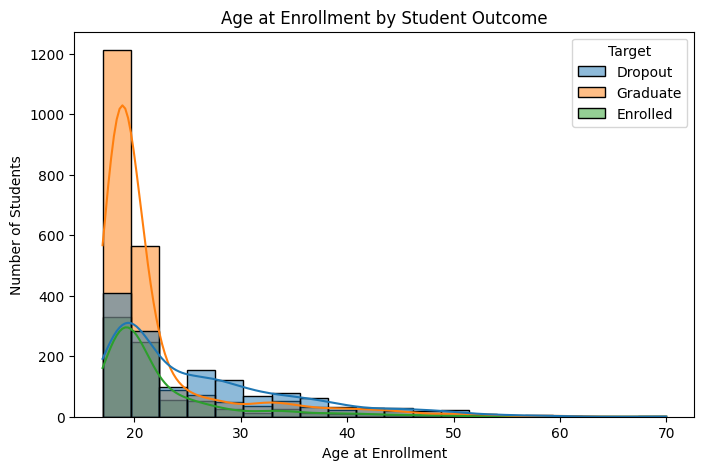

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age at enrollment", hue="Target",
             kde=True, bins=20)

plt.title("Age at Enrollment by Student Outcome")
plt.xlabel("Age at Enrollment")
plt.ylabel("Number of Students")
plt.show()

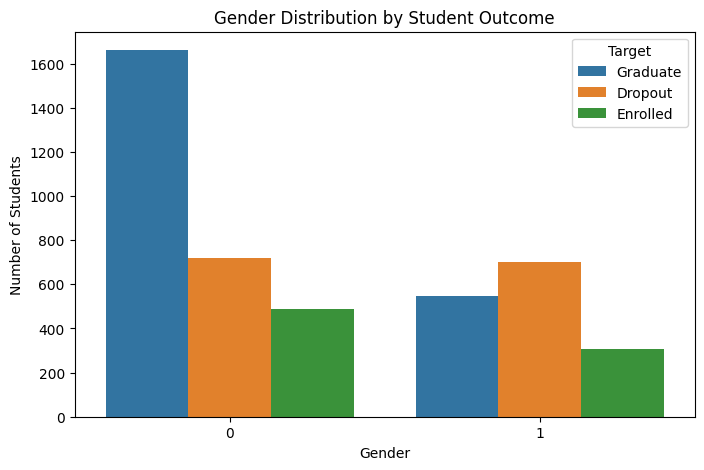

In [18]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Gender", hue="Target")

plt.title("Gender Distribution by Student Outcome")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.show()

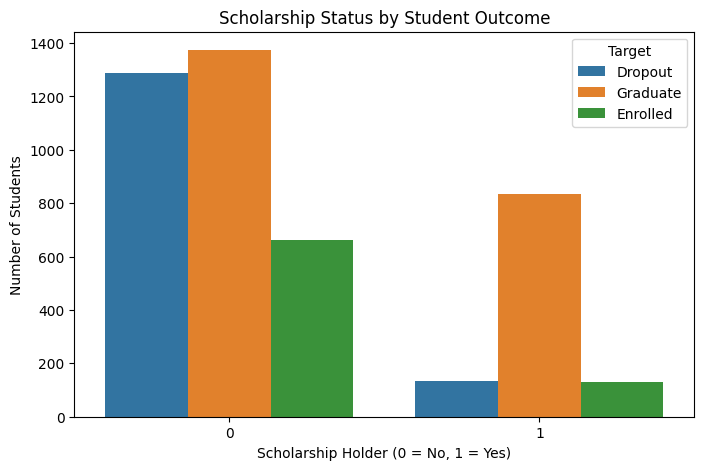

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Scholarship holder", hue="Target")

plt.title("Scholarship Status by Student Outcome")
plt.xlabel("Scholarship Holder (0 = No, 1 = Yes)")
plt.ylabel("Number of Students")
plt.show()

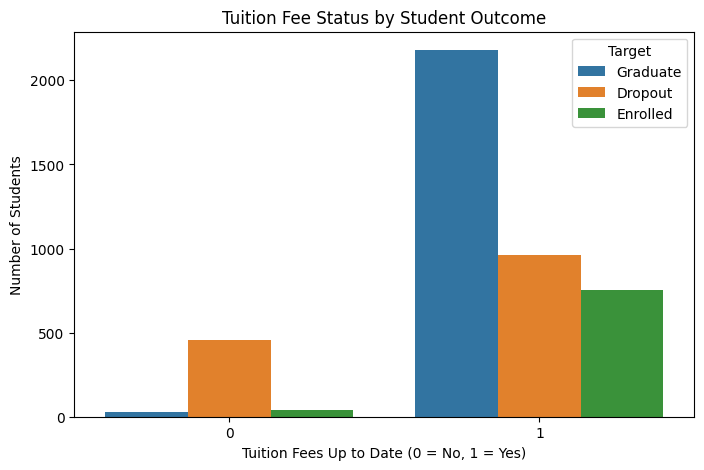

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Tuition fees up to date", hue="Target")

plt.title("Tuition Fee Status by Student Outcome")
plt.xlabel("Tuition Fees Up to Date (0 = No, 1 = Yes)")
plt.ylabel("Number of Students")
plt.show()

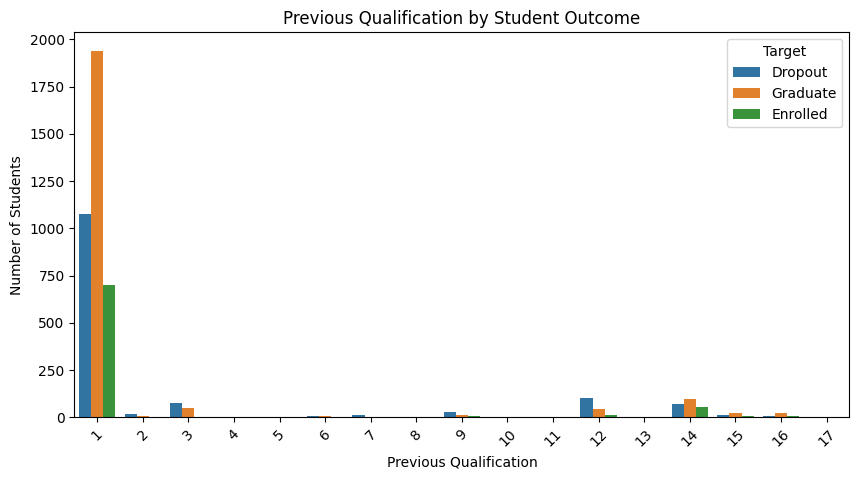

In [21]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x="Previous qualification", hue="Target")

plt.title("Previous Qualification by Student Outcome")
plt.xlabel("Previous Qualification")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)

plt.show()

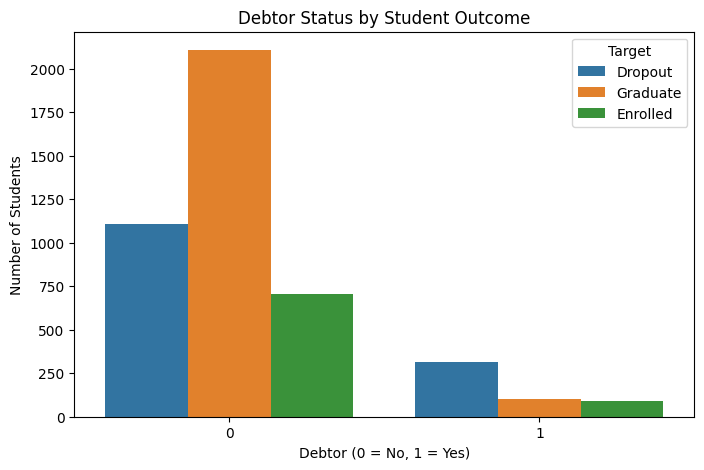

In [22]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Debtor", hue="Target")

plt.title("Debtor Status by Student Outcome")
plt.xlabel("Debtor (0 = No, 1 = Yes)")
plt.ylabel("Number of Students")
plt.show()

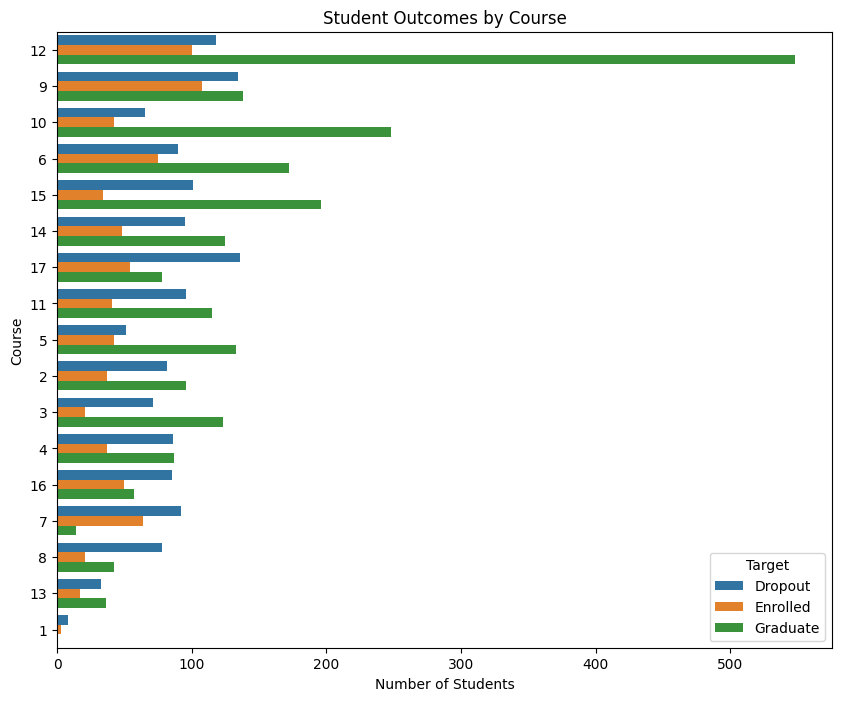

In [23]:
plt.figure(figsize=(10, 8))

sns.countplot(
    data=df,
    y="Course",
    hue="Target",
    order=df["Course"].value_counts().index
)

plt.title("Student Outcomes by Course")
plt.xlabel("Number of Students")
plt.ylabel("Course")

plt.show()

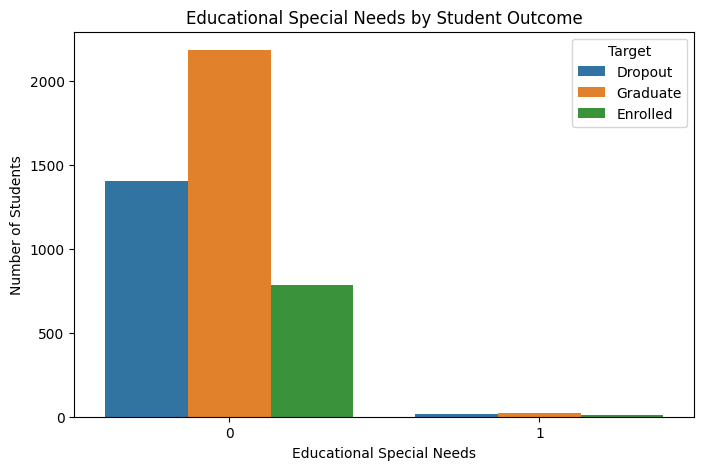

In [24]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Educational special needs", hue="Target")

plt.title("Educational Special Needs by Student Outcome")
plt.xlabel("Educational Special Needs")
plt.ylabel("Number of Students")
plt.show()

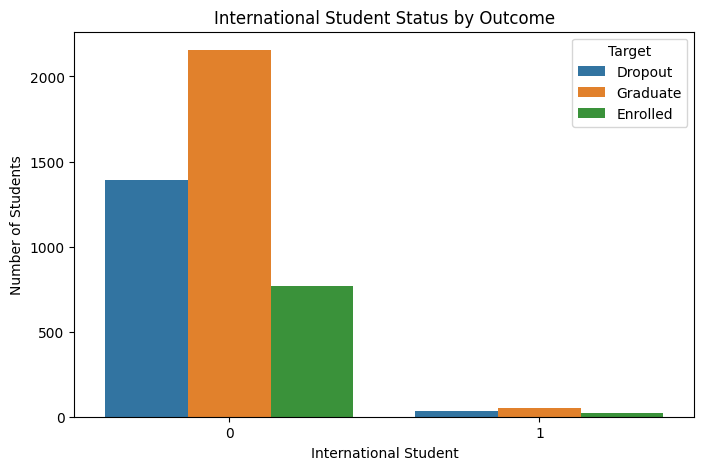

In [25]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="International", hue="Target")

plt.title("International Student Status by Outcome")
plt.xlabel("International Student")
plt.ylabel("Number of Students")
plt.show()

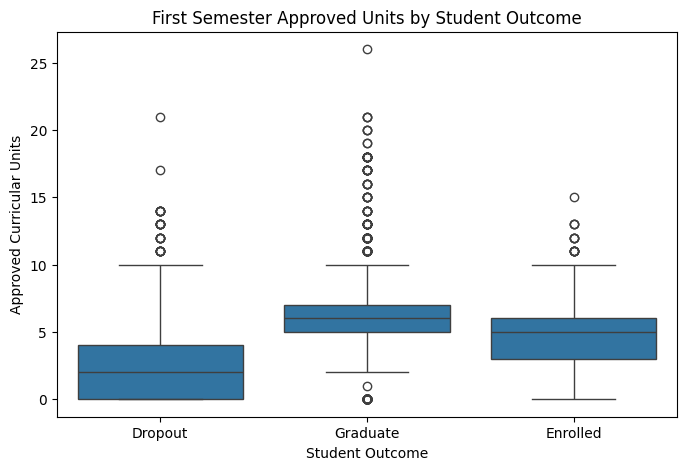

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Target", y="Curricular units 1st sem (approved)")

plt.title("First Semester Approved Units by Student Outcome")
plt.xlabel("Student Outcome")
plt.ylabel("Approved Curricular Units")
plt.show()

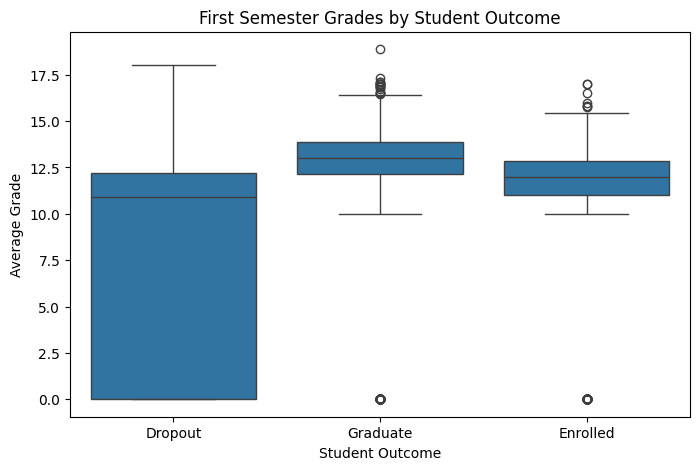

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Target", y="Curricular units 1st sem (grade)")

plt.title("First Semester Grades by Student Outcome")
plt.xlabel("Student Outcome")
plt.ylabel("Average Grade")
plt.show()

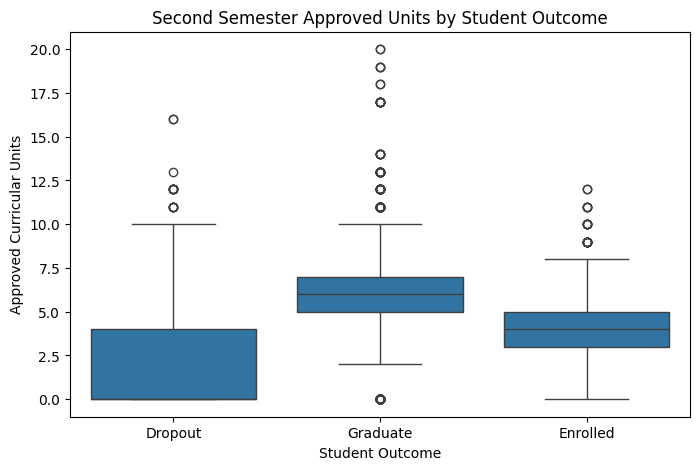

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Target", y="Curricular units 2nd sem (approved)")

plt.title("Second Semester Approved Units by Student Outcome")
plt.xlabel("Student Outcome")
plt.ylabel("Approved Curricular Units")
plt.show()

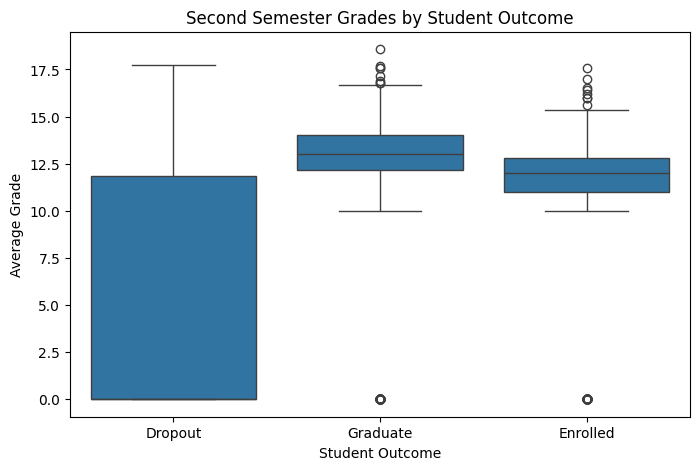

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Target", y="Curricular units 2nd sem (grade)")

plt.title("Second Semester Grades by Student Outcome")
plt.xlabel("Student Outcome")
plt.ylabel("Average Grade")
plt.show()

In [30]:
academic_summary = df.groupby("Target")[
    [
        "Curricular units 1st sem (approved)",
        "Curricular units 1st sem (grade)",
        "Curricular units 2nd sem (approved)",
        "Curricular units 2nd sem (grade)"
    ]
].mean().round(2)

display(academic_summary)

,Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade)
Target,,,,
Dropout,2.55,7.26,1.94,5.90
Enrolled,4.32,11.13,4.06,11.12
Graduate,6.23,12.64,6.18,12.70


## Data Preprocessing

The target variable `Target` contains three possible outcomes: Dropout, Enrolled, and Graduate.

The input features contain demographic, enrollment, financial, academic, and socioeconomic information. Some variables are numerical measurements, while others are categorical variables represented by numeric codes.

Categorical variables will be one-hot encoded, while numerical variables will be passed through without scaling.

In [31]:
X = df.drop(columns=["Target"])
y = df["Target"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget classes:")
print(y.unique())

Feature shape: (4424, 34)
Target shape: (4424,)

Target classes:
['Dropout' 'Graduate' 'Enrolled']


In [32]:
categorical_features = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

print("Categorical features:", len(categorical_features))
print(categorical_features)

Categorical features: 18
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']


In [33]:
numeric_features = [
    column for column in X.columns
    if column not in categorical_features
]

print("Numerical features:", len(numeric_features))
print(numeric_features)

Numerical features: 16
['Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']


In [34]:
numeric_features = [
    column for column in X.columns
    if column not in categorical_features
]

print("Numerical features:", len(numeric_features))
print(numeric_features)

Numerical features: 16
['Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set: (3539, 34)
Testing set: (885, 34)

Training target distribution:
Target
Graduate    1767
Dropout     1137
Enrolled     635
Name: count, dtype: int64

Testing target distribution:
Target
Graduate    442
Dropout     284
Enrolled    159
Name: count, dtype: int64


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set: (3539, 34)
Testing set: (885, 34)

Training target distribution:
Target
Graduate    1767
Dropout     1137
Enrolled     635
Name: count, dtype: int64

Testing target distribution:
Target
Graduate    442
Dropout     284
Enrolled    159
Name: count, dtype: int64


In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [40]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original training features:", X_train.shape[1])
print("Processed training features:", X_train_processed.shape[1])

Original training features: 34
Processed training features: 249


## Machine Learning Model 1: Logistic Regression

Logistic Regression is used as a baseline classification model. Although its name contains "regression", it can be used for multiclass classification and provides a useful reference point for evaluating the more complex Random Forest model.

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


## Machine Learning Model 2: Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees. It can capture nonlinear relationships and interactions between features and is suitable for multiclass classification.

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [43]:
print("First 10 actual outcomes:")
print(y_test.iloc[:10].values)

print("\nFirst 10 Logistic Regression predictions:")
print(y_pred_lr[:10])

print("\nFirst 10 Random Forest predictions:")
print(y_pred_rf[:10])

First 10 actual outcomes:
['Graduate' 'Graduate' 'Enrolled' 'Graduate' 'Graduate' 'Graduate'
 'Graduate' 'Graduate' 'Graduate' 'Graduate']

First 10 Logistic Regression predictions:
['Graduate' 'Graduate' 'Dropout' 'Graduate' 'Graduate' 'Dropout'
 'Graduate' 'Graduate' 'Graduate' 'Graduate']

First 10 Random Forest predictions:
['Graduate' 'Graduate' 'Dropout' 'Graduate' 'Graduate' 'Graduate'
 'Graduate' 'Graduate' 'Graduate' 'Graduate']


## Model Evaluation

The trained models are evaluated using accuracy, precision, recall, F1-score, classification reports, and confusion matrices.

Because this is a multiclass classification problem, both weighted and macro-averaged metrics are considered.

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

class_names = ["Dropout", "Enrolled", "Graduate"]

print("Evaluation metrics imported successfully!")

Evaluation metrics imported successfully!


In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

class_names = ["Dropout", "Enrolled", "Graduate"]

print("Evaluation metrics imported successfully!")

Evaluation metrics imported successfully!


In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

class_names = ["Dropout", "Enrolled", "Graduate"]

print("Evaluation metrics imported successfully!")

Evaluation metrics imported successfully!


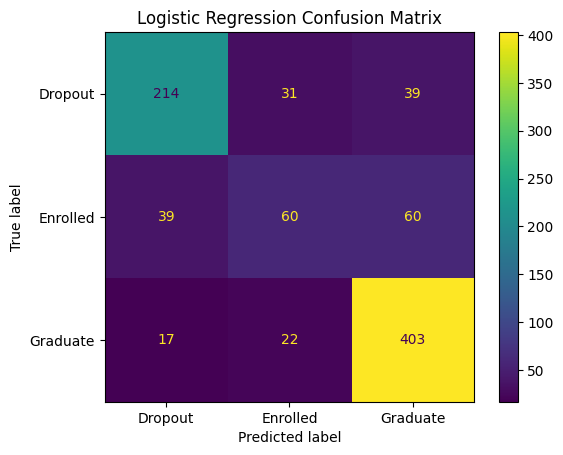

In [47]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=class_names
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [48]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average="weighted")
rf_recall = recall_score(y_test, y_pred_rf, average="weighted")
rf_f1 = f1_score(y_test, y_pred_rf, average="weighted")

print("Random Forest Results")
print("---------------------")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-score:  {rf_f1:.4f}")

Random Forest Results
---------------------
Accuracy:  0.7627
Precision: 0.7445
Recall:    0.7627
F1-score:  0.7439


In [49]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average="weighted")
rf_recall = recall_score(y_test, y_pred_rf, average="weighted")
rf_f1 = f1_score(y_test, y_pred_rf, average="weighted")

print("Random Forest Results")
print("---------------------")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-score:  {rf_f1:.4f}")

Random Forest Results
---------------------
Accuracy:  0.7627
Precision: 0.7445
Recall:    0.7627
F1-score:  0.7439


In [50]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average="weighted")
rf_recall = recall_score(y_test, y_pred_rf, average="weighted")
rf_f1 = f1_score(y_test, y_pred_rf, average="weighted")

print("Random Forest Results")
print("---------------------")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-score:  {rf_f1:.4f}")

Random Forest Results
---------------------
Accuracy:  0.7627
Precision: 0.7445
Recall:    0.7627
F1-score:  0.7439


In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, average="weighted")
lr_recall = recall_score(y_test, y_pred_lr, average="weighted")
lr_f1 = f1_score(y_test, y_pred_lr, average="weighted")

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-score:  {lr_f1:.4f}")

Logistic Regression Results
---------------------------
Accuracy:  0.7650
Precision: 0.7507
Recall:    0.7650
F1-score:  0.7536


In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, average="weighted")
lr_recall = recall_score(y_test, y_pred_lr, average="weighted")
lr_f1 = f1_score(y_test, y_pred_lr, average="weighted")

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-score:  {lr_f1:.4f}")

Logistic Regression Results
---------------------------
Accuracy:  0.7650
Precision: 0.7507
Recall:    0.7650
F1-score:  0.7536


In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, average="weighted")
lr_recall = recall_score(y_test, y_pred_lr, average="weighted")
lr_f1 = f1_score(y_test, y_pred_lr, average="weighted")

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-score:  {lr_f1:.4f}")

Logistic Regression Results
---------------------------
Accuracy:  0.7650
Precision: 0.7507
Recall:    0.7650
F1-score:  0.7536


## Feature Importance Analysis

Feature importance is used to identify which input variables contribute most to the Random Forest model's predictions.

This analysis helps interpret the model and understand which demographic, academic, financial, and enrollment-related variables are most influential in classification.

In [56]:
# Extract the trained Random Forest model
rf_classifier = rf_model.named_steps["classifier"]

# Get the fitted preprocessing component
fitted_preprocessor = rf_model.named_steps["preprocessor"]

# Get feature names after one-hot encoding
feature_names = fitted_preprocessor.get_feature_names_out()

# Get Random Forest feature importance
importance_values = rf_classifier.feature_importances_

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(20))

,Feature,Importance
243,numeric__Curricular units 2nd sem (approved),0.106936
244,numeric__Curricular units 2nd sem (grade),0.083861
237,numeric__Curricular units 1st sem (approved),0.079748
238,numeric__Curricular units 1st sem (grade),0.058040
242,numeric__Curricular units 2nd sem (evaluations),0.040058
236,numeric__Curricular units 1st sem (evaluations),0.035100
233,numeric__Age at enrollment,0.032904
225,categorical__Tuition fees up to date_0,0.026128
226,categorical__Tuition fees up to date_1,0.023406
246,numeric__Unemployment rate,0.021914


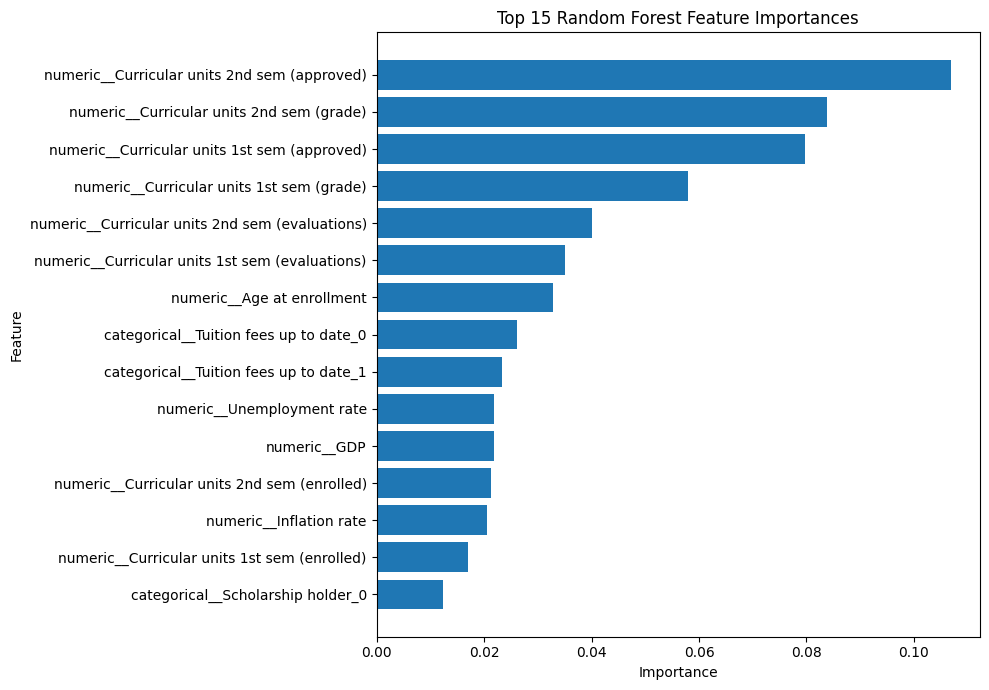

In [57]:
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Sample Student Outcome Prediction

The trained Random Forest model is used to predict the academic outcome of a new student based on demographic, enrollment, financial, and academic characteristics.

In [58]:
# Create a sample student using the original feature columns
sample_student = X.iloc[[0]].copy()

print("Sample student input:")
display(sample_student)

Sample student input:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0,0.0,0,10.8,1.4,1.74


In [59]:
sample_prediction = rf_model.predict(sample_student)

print("Predicted Student Outcome:", sample_prediction[0])

Predicted Student Outcome: Dropout


In [60]:
sample_probabilities = rf_model.predict_proba(sample_student)

probability_df = pd.DataFrame(
    sample_probabilities,
    columns=rf_model.named_steps["classifier"].classes_
)

display(probability_df)

,Dropout,Enrolled,Graduate
0,0.765,0.04,0.195


In [61]:
sample_probabilities = rf_model.predict_proba(sample_student)

probability_df = pd.DataFrame(
    sample_probabilities,
    columns=rf_model.named_steps["classifier"].classes_
)

display(probability_df)

,Dropout,Enrolled,Graduate
0,0.765,0.04,0.195


# Final Project Summary

## Objective

The objective of this project was to develop a machine learning classification system capable of predicting student academic outcomes as:

- Dropout
- Enrolled
- Graduate

The project followed a complete machine learning workflow including data exploration, preprocessing, model training, evaluation, feature importance analysis, and sample prediction.

## Dataset

The dataset contains 4,424 student records and 35 columns.

The target variable contains three academic outcomes:

- Graduate
- Dropout
- Enrolled

There were no missing values or exact duplicate records in the dataset.

## Machine Learning Models

Two classification algorithms were developed:

1. Logistic Regression
2. Random Forest

Categorical variables were processed using One-Hot Encoding, while numerical variables were passed through the preprocessing pipeline.

The dataset was divided into 80% training data and 20% testing data using stratified sampling.

## Evaluation

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Classification Report
- Confusion Matrix

Weighted and macro-averaged metrics were considered because the target classes have different numbers of observations.

## Feature Importance

Random Forest feature importance was analyzed to identify the variables that contributed most strongly to the model's predictions.

Feature importance indicates the variables the model relied on for prediction and should not be interpreted as evidence of direct causation.

## Sample Prediction

A sample student record was passed through the trained Random Forest model to demonstrate how the system can classify a student's academic outcome and provide class probabilities.

## Conclusion

This project demonstrates an end-to-end multiclass machine learning workflow for student outcome classification.

The resulting system can be used as an analytical tool to identify patterns associated with different academic outcomes. However, predictions should be treated as model-based estimates rather than certain outcomes.

A future version could focus specifically on early-warning prediction by restricting the model to information available before a student reaches the later stages of their academic program.

In [63]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Logistic Regression metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, average="weighted")
lr_recall = recall_score(y_test, y_pred_lr, average="weighted")
lr_f1 = f1_score(y_test, y_pred_lr, average="weighted")
lr_macro_f1 = f1_score(y_test, y_pred_lr, average="macro")

# Random Forest metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average="weighted")
rf_recall = recall_score(y_test, y_pred_rf, average="weighted")
rf_f1 = f1_score(y_test, y_pred_rf, average="weighted")
rf_macro_f1 = f1_score(y_test, y_pred_rf, average="macro")

# Comparison table
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],
    "Precision (Weighted)": [
        lr_precision,
        rf_precision
    ],
    "Recall (Weighted)": [
        lr_recall,
        rf_recall
    ],
    "F1-Score (Weighted)": [
        lr_f1,
        rf_f1
    ],
    "F1-Score (Macro)": [
        lr_macro_f1,
        rf_macro_f1
    ]
})

results = results.round(4)

print("FINAL MODEL COMPARISON")
print("======================")

display(results)

print("\nMacro F1 Scores:")
print(f"Logistic Regression: {lr_macro_f1:.4f}")
print(f"Random Forest:       {rf_macro_f1:.4f}")

FINAL MODEL COMPARISON


,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted),F1-Score (Macro)
0,Logistic Regression,0.7650,0.7507,0.7650,0.7536,0.6892
1,Random Forest,0.7627,0.7445,0.7627,0.7439,0.6729



Macro F1 Scores:
Logistic Regression: 0.6892
Random Forest:       0.6729
